# Classification d'expressions faciales avec des primitives GLCM (RAF-DB)

Deuxième partie du projet. À partir des vecteurs de 320 primitives GLCM/Haralick extraits dans le notebook 01, j'entraîne et je compare plusieurs classifieurs sur les 7 expressions de RAF-DB. C'est un projet personnel, fait à partir des énoncés et des supports du cours GTI771 (ÉTS Montréal).

## Fichiers utilisés (générés par le notebook 01)

- `split-train-orig-glcm-zone4x4.h5` : images originales du train (9 803 × 320)
- `split-train-aug-glcm-zone4x4.h5` : images synthétiques, dérivées du train uniquement (16 888 × 320)
- `split-val-glcm-zone4x4.h5` : validation, images originales jamais augmentées (2 451 × 320)
- `data-cleaned-pre-test-glcm-zone4x4.h5` : jeu de test sans étiquettes (3 064 × 320)

## Ce que fait le notebook

1. Chargement des fichiers, et vérification qu'aucune image de validation (ni aucun de ses dérivés) n'est dans le train
2. Trois modèles de base : régression logistique, Random Forest, SVM RBF
3. Test de l'augmentation d'images avec un Random Forest
4. Tests de fuite entre train et validation
5. Comparaison avec le F1 macro (l'accuracy serait trompeuse : Happiness représente environ 39 % des images)
6. Prédictions sur le jeu de test avec le meilleur modèle

## 0. Imports

In [13]:
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid')

LABELS_NAMES = {
    1: 'Surprise', 2: 'Fear', 3: 'Disgust',
    4: 'Happiness', 5: 'Sadness', 6: 'Anger', 7: 'Neutral'
}
TARGET_NAMES = [LABELS_NAMES[i] for i in range(1, 8)]

## 1. Chargement des fichiers HDF5

Ajuster les chemins si besoin (adapter à Google Drive, Colab, ou exécution locale).

In [14]:
# ============================================================
# CONFIGURATION — adapter uniquement cette cellule
# ============================================================
import os, sys
import h5py
import numpy as np
import pandas as pd

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/gti771/tp1'
else:
    BASE_DIR = '.'

PATH_TRAIN_ORIG = os.path.join(BASE_DIR, 'split-train-orig-glcm-zone4x4.h5')
PATH_TRAIN_AUG  = os.path.join(BASE_DIR, 'split-train-aug-glcm-zone4x4.h5')
PATH_VAL        = os.path.join(BASE_DIR, 'split-val-glcm-zone4x4.h5')
PATH_TEST       = os.path.join(BASE_DIR, 'data-cleaned-pre-test-glcm-zone4x4.h5')

print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local'}")

def load_h5_train(path):
    """Charge un fichier HDF5 d'entraînement ou de validation (features, labels, noms de fichiers)."""
    with h5py.File(path, 'r') as hf:
        X = hf['features'][:]
        y = hf['labels'][:]
        noms = [n.decode('utf-8') for n in hf['filenames'][:]]
    return X, y, noms

def load_h5_test(path):
    """Charge un fichier HDF5 de test (features + filenames, pas de labels)."""
    with h5py.File(path, 'r') as hf:
        X = hf['features'][:]
        filenames = [name.decode('utf-8') for name in hf['filenames'][:]]
    return X, filenames

X_tr, y_tr, noms_tr = load_h5_train(PATH_TRAIN_ORIG)       # train : images originales
X_aug, y_aug, noms_aug = load_h5_train(PATH_TRAIN_AUG)     # train : images synthétiques
X_val, y_val, noms_val = load_h5_train(PATH_VAL)           # validation : originales, jamais augmentées
X_test_final, test_filenames = load_h5_test(PATH_TEST)

# Train enrichi = originales du train + synthétiques dérivées du train
X_tr_reeq = np.vstack([X_tr, X_aug])
y_tr_reeq = np.concatenate([y_tr, y_aug])
# Pour l'entraînement final (section 11) : tout le jeu original, train + validation
X_train_norm = np.vstack([X_tr, X_val])
y_train_norm = np.concatenate([y_tr, y_val])

# Garde-fous structurels : aucune image de validation, ni aucun dérivé, dans l'entraînement
sources_aug = {n.split('_aug')[0] + '.jpg' for n in noms_aug}
assert set(noms_tr).isdisjoint(noms_val), "Une image est à la fois en train et en validation"
assert sources_aug.isdisjoint(noms_val), "Une image synthétique dérive d'une image de validation"
assert sources_aug.issubset(noms_tr), "Une image synthétique dérive d'une image hors train"

print(f"Train (originales) : {X_tr.shape} | synthétiques : {X_aug.shape} | train enrichi : {X_tr_reeq.shape}")
print(f"Validation : {X_val.shape} | test (sans labels) : {X_test_final.shape}")

Environnement : Local
Train (originales) : (9803, 320) | synthétiques : (16888, 320) | train enrichi : (26691, 320)
Validation : (2451, 320) | test (sans labels) : (3064, 320)


## 2. Visualisation rapide des distributions

Confirme que le rééquilibrage produit bien une distribution uniforme.

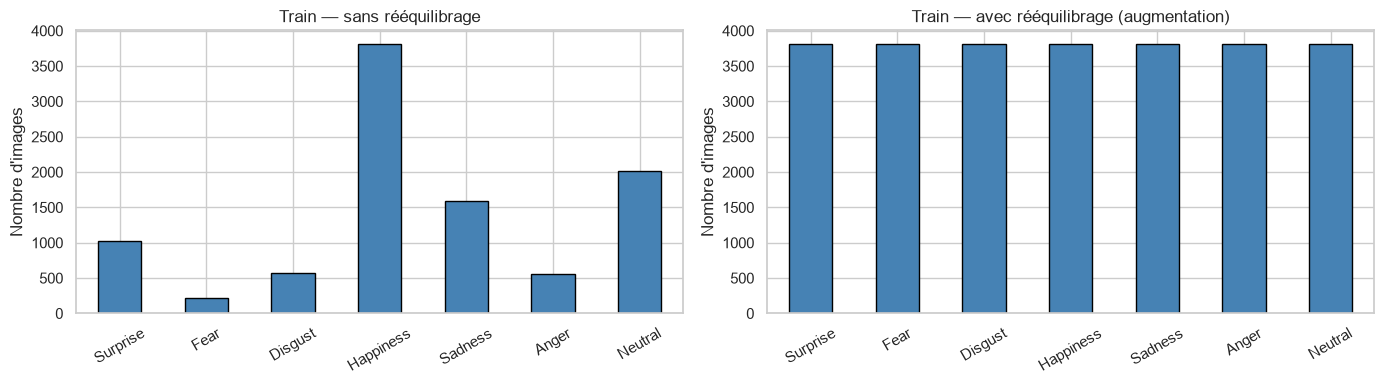

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y, title in zip(
    axes,
    [y_tr, y_tr_reeq],
    ['Train — sans rééquilibrage', 'Train — avec rééquilibrage (augmentation)']
):
    counts = pd.Series(y).map(LABELS_NAMES).value_counts().reindex(TARGET_NAMES)
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel("Nombre d'images")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Découpage train / validation

Le découpage est fait dans le notebook 01 (stratifié 80/20, graine 42), avant toute augmentation. La validation est représentative de la distribution réelle et n'est jamais augmentée.

In [16]:
print(f"Train : {X_tr.shape} — Validation : {X_val.shape}")
print("\nDistribution de la validation (représentative du réel) :")
print(pd.Series(y_val).map(LABELS_NAMES).value_counts().reindex(TARGET_NAMES).to_string())

Train : (9803, 320) — Validation : (2451, 320)

Distribution de la validation (représentative du réel) :
Surprise     258
Fear          56
Disgust      143
Happiness    954
Sadness      396
Anger        141
Neutral      503


## 4. Fonction d'évaluation commune

Rapporte F1 macro, F1 par classe, et affiche la matrice de confusion.

In [17]:
def evaluer_modele(nom, pipeline, X_train, y_train, X_val, y_val):
    """Entraîne le pipeline et rapporte les métriques de validation."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    f1_macro = f1_score(y_val, y_pred, average='macro')

    print(f"\n{'=' * 60}")
    print(f"  {nom}")
    print(f"{'=' * 60}")
    print(f"F1 macro : {f1_macro:.4f}")
    print(f"\nRapport de classification (validation) :")
    print(classification_report(y_val, y_pred, target_names=TARGET_NAMES, digits=3))

    return {'nom': nom, 'pipeline': pipeline, 'f1_macro': f1_macro, 'y_pred': y_pred}


def afficher_matrice_confusion(y_true, y_pred, titre):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[0])
    axes[0].set_title(f'{titre} — effectifs bruts')
    axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[1])
    axes[1].set_title(f'{titre} — normalisée par ligne')
    axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')

    plt.tight_layout()
    plt.show()

## 5. Modèle 1 — Régression logistique (baseline)

Baseline linéaire. Rapide, permet de savoir si les primitives GLCM sont linéairement séparables.


  Logistic Regression (sans rééquilibrage)
F1 macro : 0.2784

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.348     0.178     0.236       258
        Fear      0.390     0.286     0.330        56
     Disgust      0.100     0.007     0.013       143
   Happiness      0.475     0.754     0.583       954
     Sadness      0.329     0.250     0.284       396
       Anger      0.311     0.135     0.188       141
     Neutral      0.359     0.280     0.315       503

    accuracy                          0.425      2451
   macro avg      0.330     0.270     0.278      2451
weighted avg      0.381     0.425     0.381      2451



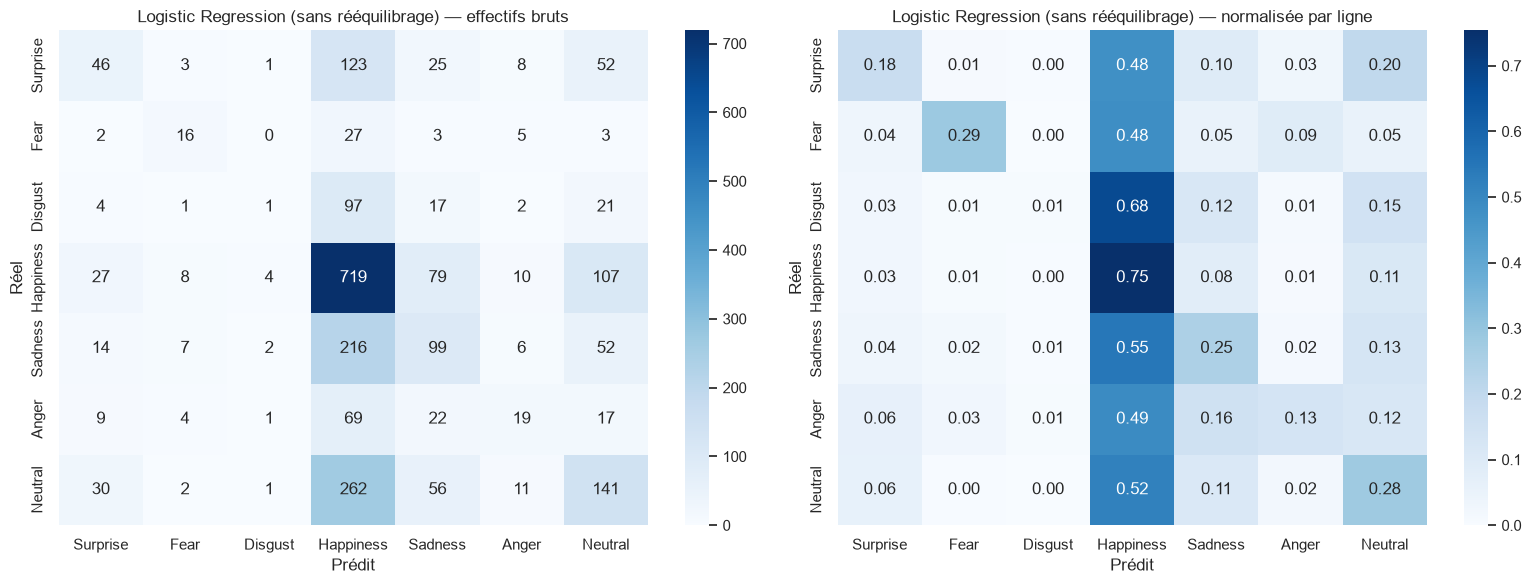

In [18]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

res_lr = evaluer_modele('Logistic Regression (sans rééquilibrage)',
                        pipeline_lr, X_tr, y_tr, X_val, y_val)
afficher_matrice_confusion(y_val, res_lr['y_pred'], res_lr['nom'])

## 6. Modèle 2 — Random Forest

Capture les interactions non linéaires entre les 320 dimensions. `class_weight='balanced'` compense automatiquement le déséquilibre sans avoir à ré-échantillonner.


  Random Forest (class_weight=balanced)
F1 macro : 0.2691

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.216     0.124     0.158       258
        Fear      0.500     0.339     0.404        56
     Disgust      0.000     0.000     0.000       143
   Happiness      0.500     0.603     0.546       954
     Sadness      0.294     0.361     0.324       396
       Anger      0.200     0.106     0.139       141
     Neutral      0.300     0.326     0.313       503

    accuracy                          0.387      2451
   macro avg      0.287     0.266     0.269      2451
weighted avg      0.349     0.387     0.363      2451



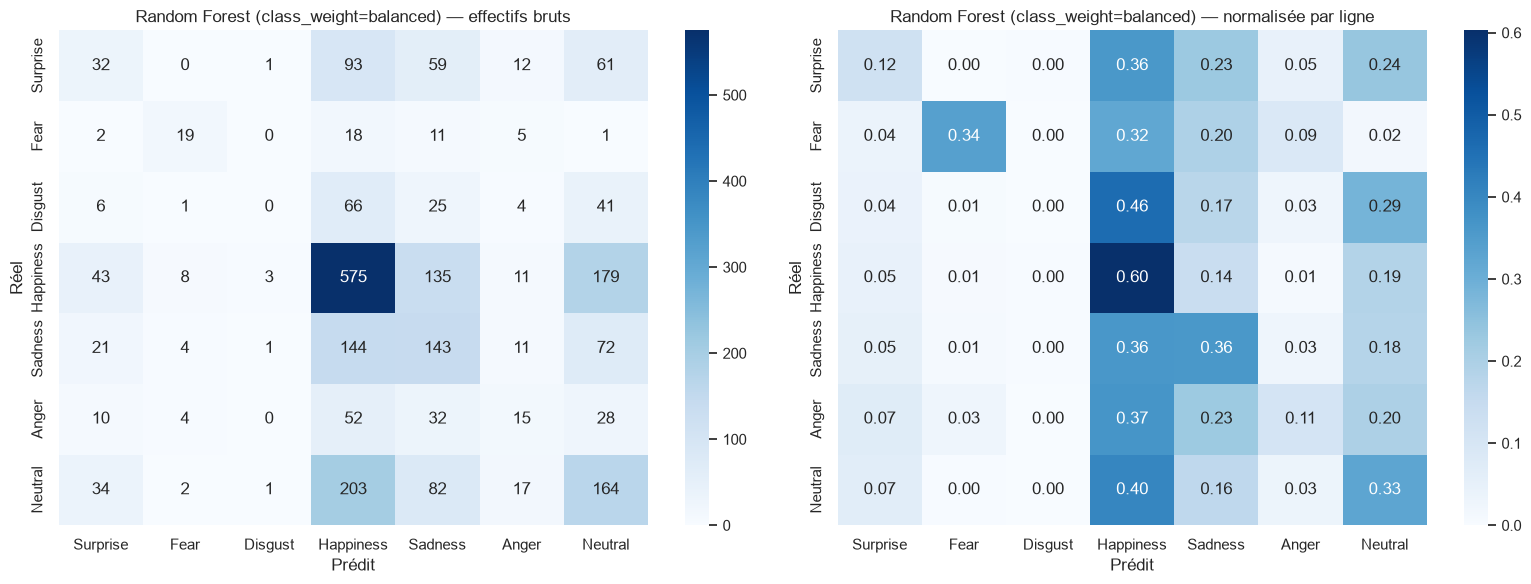

In [19]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

res_rf = evaluer_modele('Random Forest (class_weight=balanced)',
                        pipeline_rf, X_tr, y_tr, X_val, y_val)
afficher_matrice_confusion(y_val, res_rf['y_pred'], res_rf['nom'])

## 7. Modèle 3 — SVM RBF

Classifieur non linéaire de référence. Peut être lent : ne pas s'inquiéter si la cellule prend plusieurs minutes.


  SVM RBF (class_weight=balanced)
F1 macro : 0.2536

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.198     0.252     0.222       258
        Fear      0.187     0.411     0.257        56
     Disgust      0.093     0.140     0.112       143
   Happiness      0.565     0.347     0.430       954
     Sadness      0.288     0.318     0.302       396
       Anger      0.124     0.227     0.160       141
     Neutral      0.292     0.292     0.292       503

    accuracy                          0.304      2451
   macro avg      0.250     0.284     0.254      2451
weighted avg      0.364     0.304     0.321      2451



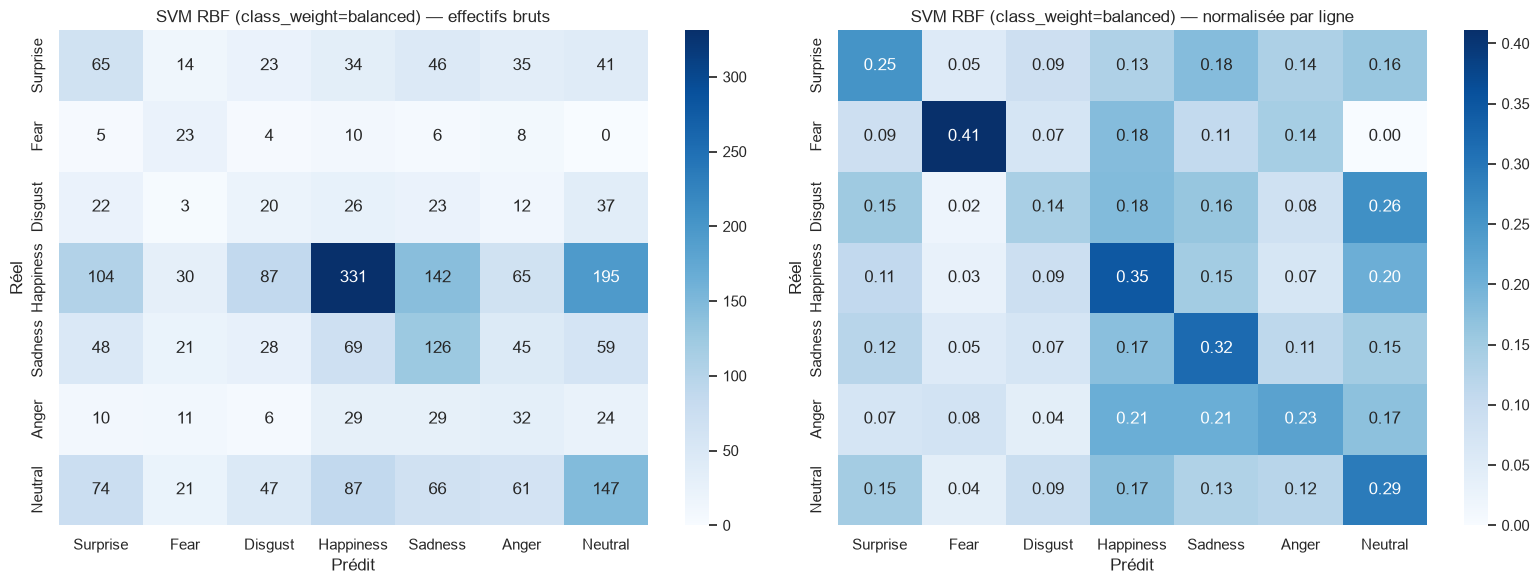

In [20]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', random_state=42))
])

res_svm = evaluer_modele('SVM RBF (class_weight=balanced)',
                         pipeline_svm, X_tr, y_tr, X_val, y_val)
afficher_matrice_confusion(y_val, res_svm['y_pred'], res_svm['nom'])

## 8. Rééquilibrage des classes : augmentation d'images et vérification

**Question.** Un rééquilibrage apporte-t-il quelque chose au-delà de `class_weight='balanced'` ?

### 8.1 Augmentation d'images (retournements, rotations de ±15°)

Le découpage train/validation est fait **avant** l'augmentation (notebook 01) : les images synthétiques ne dérivent que d'images du train, et la validation n'est jamais augmentée. Le Random Forest est entraîné sur le train enrichi et évalué sur la même validation que les autres modèles.

> **Historique.** Une première version de cette évaluation découpait les images après l'augmentation et annonçait un F1 macro de 0,8908. Ce résultat était invalide : 80,0 % des vecteurs de validation se retrouvaient à l'identique dans l'entraînement, avec de nombreuses copies retournées ou tournées (pour la classe Fear, distance au plus proche voisin de 2,69 contre 8,36). Le protocole ci-dessus le corrige.

In [21]:
resultats = [res_lr, res_rf, res_svm]
meilleur = max(resultats, key=lambda r: r['f1_macro'])
print(f"Meilleur modèle sans rééquilibrage : {meilleur['nom']} (F1 macro = {meilleur['f1_macro']:.4f})")
print(f"Train original : {X_tr.shape} | train enrichi (augmentation d'images) : {X_tr_reeq.shape}")

Meilleur modèle sans rééquilibrage : Logistic Regression (sans rééquilibrage) (F1 macro = 0.2784)
Train original : (9803, 320) | train enrichi (augmentation d'images) : (26691, 320)



  Random Forest — train enrichi (augmentation d'images)
F1 macro : 0.2395

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.164     0.101     0.125       258
        Fear      0.284     0.411     0.336        56
     Disgust      0.027     0.021     0.024       143
   Happiness      0.467     0.577     0.516       954
     Sadness      0.302     0.301     0.301       396
       Anger      0.104     0.113     0.108       141
     Neutral      0.312     0.233     0.267       503

    accuracy                          0.348      2451
   macro avg      0.237     0.251     0.240      2451
weighted avg      0.326     0.348     0.333      2451



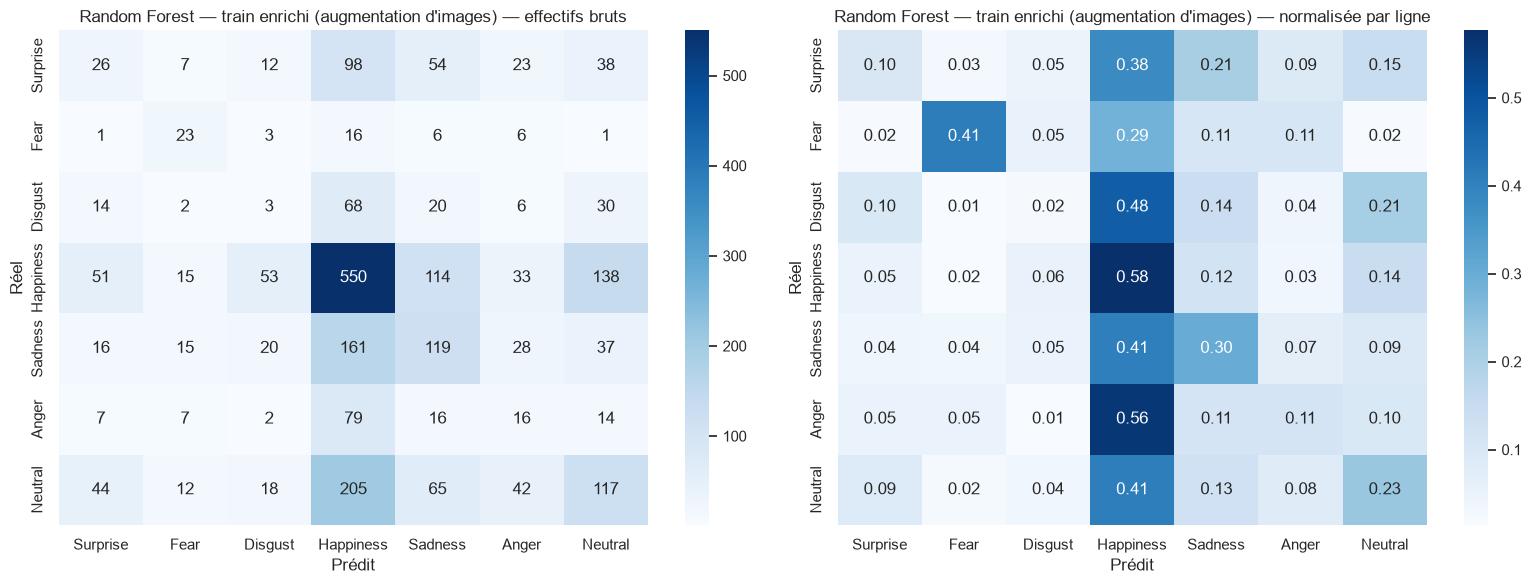

In [22]:
# Random Forest sans class_weight, sur le jeu déjà rééquilibré par augmentation
pipeline_rf_aug = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# On évalue sur la validation représentative (non augmentée)
res_rf_aug = evaluer_modele(
    "Random Forest — train enrichi (augmentation d'images)",
    pipeline_rf_aug, X_tr_reeq, y_tr_reeq, X_val, y_val
)
afficher_matrice_confusion(y_val, res_rf_aug['y_pred'], res_rf_aug['nom'])

### 8.2 Vérification : plus aucune fuite

In [23]:
import hashlib
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Test 1 : vecteurs de validation identiques à un vecteur du train enrichi
def cle(v):
    return hashlib.md5(v.tobytes()).hexdigest()

index_train = defaultdict(list)
for nom, v in zip(noms_tr + noms_aug, X_tr_reeq):          # même ordre que X_tr_reeq
    index_train[cle(v)].append(nom)

doublons = [(nom, index_train[cle(v)]) for nom, v in zip(noms_val, X_val) if cle(v) in index_train]
print(f"Test 1 : {len(doublons)} / {len(X_val)} vecteurs de validation identiques à un vecteur du train enrichi")
for nom_val, noms_train in doublons:
    print(f"   {nom_val}  <->  {noms_train}")

# Test 2 : distance au plus proche voisin, même protocole que pour la première version
sc = StandardScaler().fit(X_tr)
Xv = sc.transform(X_val)

def dist_voisin(ref):
    d, _ = NearestNeighbors(n_neighbors=2).fit(sc.transform(ref)).kneighbors(Xv)
    return np.where(d[:, 0] < 1e-6, d[:, 1], d[:, 0])      # on ignore une éventuelle copie exacte

d_orig = dist_voisin(X_tr)
d_reeq = dist_voisin(X_tr_reeq)
fear = (y_val == 2)
print("Test 2 : distance médiane au plus proche voisin (données standardisées)")
print(f"  toutes classes : train original = {np.median(d_orig):.2f} | train enrichi = {np.median(d_reeq):.2f}")
print(f"  classe Fear    : train original = {np.median(d_orig[fear]):.2f} | train enrichi = {np.median(d_reeq[fear]):.2f}")

Test 1 : 2 / 2451 vecteurs de validation identiques à un vecteur du train enrichi
   train_07293.jpg  <->  ['train_07297.jpg', 'train_07299.jpg']
   train_11142.jpg  <->  ['train_09922.jpg']
Test 2 : distance médiane au plus proche voisin (données standardisées)
  toutes classes : train original = 10.46 | train enrichi = 10.20
  classe Fear    : train original = 10.56 | train enrichi = 10.13


In [24]:
import hashlib
import os

def md5_fichier(chemin):
    with open(chemin, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

classe_de = dict(zip(noms_tr, y_tr))
classe_de.update(zip(noms_val, y_val))
dossier_originaux = os.path.join(BASE_DIR, 'original-train')

print("Détail des doublons : classe de chaque image et comparaison des fichiers d'origine")
for nom_val, noms_train in doublons:
    for nom_train in noms_train:
        source = nom_train.split('_aug')[0]                   # image d'origine (si c'est une image synthétique)
        if not source.endswith('.jpg'):
            source += '.jpg'
        ligne = f"  {nom_val} ({LABELS_NAMES[classe_de[nom_val]]}) <-> {source} ({LABELS_NAMES[classe_de[source]]})"
        if os.path.isdir(dossier_originaux):
            identiques = md5_fichier(os.path.join(dossier_originaux, nom_val)) == md5_fichier(os.path.join(dossier_originaux, source))
            ligne += " : fichiers " + ("identiques" if identiques else "différents")
        else:
            ligne += " : (dossier original-train absent, comparaison des fichiers impossible)"
        print(ligne)

Détail des doublons : classe de chaque image et comparaison des fichiers d'origine
  train_07293.jpg (Anger) <-> train_07297.jpg (Anger) : fichiers identiques
  train_07293.jpg (Anger) <-> train_07299.jpg (Anger) : fichiers identiques
  train_11142.jpg (Neutral) <-> train_09922.jpg (Neutral) : fichiers identiques


**Résultats des deux tests.**

- Test 1 : 2 vecteurs de validation sur 2 451 (0,08 %) sont identiques à un vecteur du train enrichi, contre 1 961 sur 2 451 (80,0 %) dans la première version. La cellule de détail ci-dessus montre qu'il s'agit d'images originales du train, pas d'images synthétiques : train_07293 (Anger) est identique à train_07297 et à train_07299, et train_11142 (Neutral) à train_09922. Leurs fichiers sont identiques octet pour octet dans l'archive RAF-DB : ce sont des doublons déjà présents dans les données d'origine.
- Test 2 (distance médiane au plus proche voisin, données standardisées) : toutes classes 10,46 avec le train original contre 10,20 avec le train enrichi ; classe Fear 10,56 contre 10,13. Dans la première version, Fear passait de 8,36 à 2,69. La distance baisse un peu parce qu'il y a plus de points dans le train, mais elle ne s'effondre plus.

Les `assert` de la cellule de chargement vérifient aussi, avec les noms de fichiers, qu'aucune image de validation ni aucun de ses dérivés n'est dans l'entraînement.

### 8.3 Les images synthétiques sont-elles distinguables des originales ?

In [25]:
from sklearn.model_selection import GroupKFold, cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Test 8.3 : L'hypothèse du "lissage"
X_det = np.vstack([X_tr, X_aug])
y_cls = np.concatenate([y_tr, y_aug])
est_synth = np.r_[np.zeros(len(X_tr)), np.ones(len(X_aug))]
groupes = np.array(noms_tr + [n.split('_aug')[0] + '.jpg' for n in noms_aug])
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Comparaison À L'INTÉRIEUR d'une classe
for classe in (5, 7):
    m = (y_cls == classe)
    auc = cross_val_score(clf, X_det[m], est_synth[m], cv=GroupKFold(n_splits=3), groups=groupes[m], scoring='roc_auc')
    print(f"{LABELS_NAMES[classe]} : AUC pour distinguer originales / synthétiques = {auc.mean():.3f}")

Sadness : AUC pour distinguer originales / synthétiques = 0.853
Neutral : AUC pour distinguer originales / synthétiques = 0.823


## 9. Synthèse comparative

In [26]:
tous = resultats + [res_rf_aug]
df_synthese = pd.DataFrame([{'Modèle': r['nom'], 'F1_macro': r['f1_macro']} for r in tous])
df_synthese.sort_values('F1_macro', ascending=False)

,Modèle,F1_macro
0,Logistic Regression (sans rééquilibrage),0.278384
1,Random Forest (class_weight=balanced),0.269096
2,SVM RBF (class_weight=balanced),0.253605
3,Random Forest — train enrichi (augmentation d'...,0.239505


In [27]:
from sklearn.metrics import f1_score
import numpy as np

# Écart de F1 macro (augmentation − class_weight) : l'écart observé est-il plus grand que le bruit de la validation ?
rng = np.random.default_rng(42)
y_a, y_b = res_rf['y_pred'], res_rf_aug['y_pred']
ecarts = []
for _ in range(1000):
    idx = rng.integers(0, len(y_val), len(y_val))
    ecarts.append(f1_score(y_val[idx], y_b[idx], average='macro') - f1_score(y_val[idx], y_a[idx], average='macro'))
bas, haut = np.percentile(ecarts, [2.5, 97.5])
print(f"Écart observé (augmentation − class_weight) : {res_rf_aug['f1_macro'] - res_rf['f1_macro']:+.4f}")
print(f"Intervalle à 95 % (bootstrap sur la validation) : [{bas:+.4f} ; {haut:+.4f}]")

Écart observé (augmentation − class_weight) : -0.0296
Intervalle à 95 % (bootstrap sur la validation) : [-0.0489 ; -0.0095]


## 10. Résultats et analyse

Les images originales sont découpées en train (9 803) et validation (2 451) avant l'augmentation. Les images synthétiques ne viennent que du train. Les `assert` de la cellule de chargement le vérifient avec les noms de fichiers, et les tests de la section 8.2 vont dans le même sens.

### Les scores

| Modèle | F1 macro |
|---|---|
| Régression logistique | 0,278 |
| Random Forest (class_weight='balanced') | 0,269 |
| SVM RBF (class_weight='balanced') | 0,254 |
| Random Forest, train enrichi par augmentation | 0,240 |

C'est faible. Pour comparer, un modèle qui répondrait toujours « Happiness » obtiendrait environ 0,08 (calculé avec la répartition de la validation) : on est au-dessus, mais pas de beaucoup. Et les quatre scores sont très proches.

### L'augmentation d'images n'apporte rien ici

Le Random Forest entraîné avec les images synthétiques fait un peu moins bien que celui avec class_weight (0,240 contre 0,269). Dans le détail, le F1 baisse pour 6 classes sur 7 (Fear passe de 0,40 à 0,34, Neutral de 0,31 à 0,27) et seul Disgust monte, de 0,00 à 0,02.

Un bootstrap sur la validation donne, pour cet écart, un intervalle à 95 % de [−0,0489 ; −0,0095] : la baisse est donc probablement réelle sur cette validation. Cet intervalle ne tient compte que du bruit de l'échantillon de validation, pas du changement de découpage ni du hasard de l'entraînement, et le même Random Forest avait eu 0,19 sur mon premier découpage contre 0,27 sur celui-ci (le SVM, lui, est resté à 0,25). Je retiens que l'augmentation n'améliore pas le Random Forest, et qu'elle le dégrade peut-être un peu. Je n'ai pas testé la régression logistique ni le SVM avec augmentation.

### Pourquoi, peut-être

Je n'ai pas de preuve, seulement des pistes. Retourner ou tourner un visage ne crée pas vraiment de nouvelle texture, et c'est la texture que mesure la GLCM. Ensuite, comme seules les classes minoritaires sont augmentées, un modèle pourrait apprendre une particularité des images synthétiques comme un indice de classe, qui ne marche plus sur de vraies images.

Le test de la section 8.3, fait à l'intérieur d'une classe pour ne pas être faussé par les proportions d'images synthétiques, donne un AUC de 0,853 pour Sadness et 0,823 pour Neutral (0,5 voudrait dire qu'on ne les distingue pas). Les primitives des images synthétiques se distinguent donc bien de celles des originales. Je ne sais pas d'où vient la différence : l'interpolation de la rotation, les bords remplis par la rotation, ou le fait que les images synthétiques sont enregistrées une seconde fois en JPEG, peut-être avec une qualité plus basse que les originales (à vérifier). Et je n'ai pas vérifié que le modèle s'en sert vraiment pour classer.

### Ce qui reste difficile

Disgust n'est presque jamais reconnue (rappel de 0,007 en régression logistique, 0,00 avec le Random Forest). Sur le jeu de test, mon meilleur modèle selon le F1 (la régression logistique) prédit Happiness pour 1 995 images sur 3 064, soit 65 %, alors que cette classe représente environ 39 % de la validation. Disgust n'est prédite que 11 fois. Le modèle est donc très tourné vers la classe majoritaire, même si son F1 est le moins mauvais des quatre.

### La fuite du début

Ma première version annonçait 0,8908 avec un Random Forest sur le jeu rééquilibré. Ce chiffre était faux : j'avais découpé après l'augmentation, et 80,0 % des vecteurs de validation se retrouvaient à l'identique dans l'entraînement, avec en plus leurs copies retournées ou tournées. Dans la version actuelle, il reste 2 vecteurs identiques sur 2 451. Ce sont des images originales du train, pas des images synthétiques : une image de la classe Anger identique à deux autres du train, et une image de la classe Neutral identique à une autre. Leurs fichiers sont identiques dans l'archive RAF-DB, ce sont donc des doublons déjà présents dans les données d'origine.

### Limites

- Une seule validation, pas de validation croisée : les petits écarts (moins de 0,03) ne disent pas grand-chose.
- Les paramètres du nettoyage (luminosité moyenne et écart-type, notebook 01) sont calculés sur tout le train original, validation comprise. Ça ne touche que 17 images, mais ce n'est pas parfaitement propre.
- Les primitives GLCM en grille 4×4 voient la texture mais pas la forme du visage. Je pense que c'est une raison des faibles scores, mais je ne l'ai pas testé.

## 11. Prédictions finales sur le jeu de test

Génère les prédictions sur le jeu de test avec le meilleur modèle, entraîné sur tout le jeu original (train et validation).

In [28]:
# On ré-entraîne le meilleur pipeline sur TOUT le train (pas de split), pour maximiser l'apprentissage
meilleur_pipeline = meilleur['pipeline']
meilleur_pipeline.fit(X_train_norm, y_train_norm)

y_test_pred = meilleur_pipeline.predict(X_test_final)

df_soumission = pd.DataFrame({
    'filename': test_filenames,
    'emotion': y_test_pred
})
df_soumission = df_soumission.sort_values('filename').reset_index(drop=True)

output_path = 'predictions_test_lab3.csv'
df_soumission.to_csv(output_path, index=False, header=False)

print(f"Prédictions sauvegardées : {output_path}")
print(f"Nombre de prédictions : {len(df_soumission)}")
print(f"\nAperçu :")
print(df_soumission.head())
print(f"\nDistribution des prédictions :")
print(df_soumission['emotion'].map(LABELS_NAMES).value_counts().to_string())

Prédictions sauvegardées : predictions_test_lab3.csv
Nombre de prédictions : 3064

Aperçu :
        filename  emotion
0  test_0001.jpg        4
1  test_0002.jpg        1
2  test_0003.jpg        4
3  test_0004.jpg        4
4  test_0005.jpg        4

Distribution des prédictions :
emotion
Happiness    1995
Neutral       471
Sadness       349
Surprise      144
Anger          53
Fear           41
Disgust        11


## 12. Ce qu'il resterait à faire (pistes)

- **Tester l'augmentation avec d'autres modèles** (régression logistique, SVM) et avec plusieurs graines ou une validation croisée, pour savoir si la baisse observée avec le Random Forest est stable.
- **Chercher l'origine de l'écart entre images synthétiques et originales** (AUC de 0,82 à 0,85) : augmentation par retournement seul (sans interpolation), enregistrement des images synthétiques avec la même qualité JPEG que les originales.
- **Augmenter aussi la classe majoritaire**, ou n'utiliser que des transformations sans effet de lissage, pour que « synthétique » ne soit plus un indice de classe.

- **Recherche d'hyperparamètres** (`GridSearchCV` ou `RandomizedSearchCV`) sur les 2-3 meilleurs modèles. `C` et `gamma` pour SVM, `n_estimators` et `max_depth` pour RF.
- **Réduction de dimensionnalité** (`PCA` conservant 95 % de la variance) — avec 320 dimensions pour ~10 000 exemples, un modèle plus régularisé pourrait mieux généraliser.
- **Comparaison avec d'autres primitives** (LBP, HOG) sur le même pipeline pour isoler l'effet du descripteur.
- **Analyse d'erreurs qualitative** : afficher 10 images mal classées de la classe la plus difficile (Fear ou Disgust) pour comprendre les patterns qui trompent le modèle.